In [1]:
#from google.colab import drive
#drive.mount('/content/drive')
import pandas as pd
import matplotlib.pyplot as plt

import numpy as np
import numpy.lib.recfunctions as rfn
from   numpy.polynomial.legendre import legval

import plotly.graph_objects as go
from ipywidgets import interact, IntSlider

from scipy.special import eval_legendre,legendre,factorial
from scipy.optimize import curve_fit, least_squares, differential_evolution

# Import des données

In [3]:
# Tableau : He-HCN
He = np.genfromtxt("Data/He-HCN.txt",
                   delimiter=",", names=True, dtype=None, encoding="utf-8")

params_He = np.array([ 1.69637,    0.18540,   0.19384,  -0.01302, -0.00719,-0.02571, # b
                      -19454.791, -23297.750,-9250.9937,-45021.967,                  # c
                       11.90598,   1.33541,   2.23321,   0.31214,  0.06321,-0.13334, # d
                       0.12724,   -0.36813,  -0.18070,   0.00010,  0.24256,-0.00422, # g0
                       0.05486,    0.08842,   0.06785,  -0.01495, -0.11374, 0.02042, # g1
                      -0.01311,    0.00038,  -0.00099,   0.00252,  0.01929,-0.00554, # g2
                       0.00053,   -0.00076,  -0.00059,   0.00002, -0.00112, 0.00036])# g3

# Conversion des µEh en mEh
energy_mEh = He['Energy'] * 1e-3
# Ajout de la colonne en Eh
He = rfn.append_fields(He, names='Energy_mEh', data=energy_mEh, usemask=False)

# Implémentation des fonctions

In [4]:
def f6_opt(x):
  y = 1.0 + x * (1.0 + x * (0.5 + x * (1.0/6.0 + x * (1.0/24.0 + x * (1.0/120.0 + x / 720.0)))))
  return 1.0 - np.exp(-x) * y

def f7_opt(x):
  y = 1.0 + x * (1.0 + x * (0.5 + x * (1.0/6.0 + x * (1.0/24.0 + x * (1.0/120.0 + x * (1.0/720.0 + x / 5040.0))))))
  return 1.0 - np.exp(-x) * y

In [41]:
def V_opt(p, R, Theta):
  R = np.asarray(R, dtype=float)
  # On calcule ces valeurs car utiles plusieurs fois
  cosTh = np.cos(np.deg2rad(np.asarray(Theta, dtype=float)))

  # Paramètres
  b  = p[0:6]                            # b0, b1, b2, b3, b4, b5
  c  = p[6:10]                           # c0, c1, c2, c3
  d  = p[10:16]                          # d0, d1, d2, d3, d4, d5
  g0 = np.asarray(p[16:22], dtype=float) # g00, g01, g02, g03, g04, g05
  g1 = np.asarray(p[22:28], dtype=float) # g10, g11, g12, g13, g14, g15
  g2 = np.asarray(p[28:34], dtype=float) # g20, g21, g22, g23, g24, g25
  g3 = np.asarray(p[34:40], dtype=float) # g30, g31, g32, g33, g34, g35

  # X(theta) ------------------------------------ #
  # --------------------------------------------- #
  X_b = legval(cosTh, b)
  X_d = legval(cosTh, d)

  X_bR = X_b * R
  abs_BR = np.abs(X_bR)
  # --------------------------------------------- #

  # G(R,theta) ---------------------------------- #
  # --------------------------------------------- #
  i = np.arange(6)
  g = g0[i, None] + R * (g1[i, None] + R * (g2[i, None] + R * g3[i, None]))
  Pl = np.array([eval_legendre(l, cosTh) for l in range(6)])
  # G = np.sum(g * Pl, axis=0)
  # ------------------------------------------- #

  # Short-Range
  exp_val = np.clip(X_d-X_bR,-200,200) # Bloquage des valeurs trop grandes/petites
  V_sh = np.sum(g * Pl, axis=0) * np.exp(exp_val)

  # Asymptotic
  inv_R = 1.0/R
  inv_R6 = inv_R * inv_R * inv_R * inv_R * inv_R * inv_R
  inv_R7 = inv_R6 * inv_R

  V_as = (f6_opt(abs_BR) * legval(cosTh,[c[0],0,c[2]]) * inv_R6
        + f7_opt(abs_BR) * legval(cosTh,[0,c[1],0,c[3]]) * inv_R7)

  V_total = V_sh + V_as

  # Pour ne pas renvoyer NaN en cas d'erreur
  V_total = np.nan_to_num(V_total, nan=1e100, posinf=1e100, neginf=-1e100)
  # Bloquage des valeurs trop grandes
  V_total = np.clip(V_total, -1e100, 1e100)
  
  return V_total # Energie renvoyée en mEh

# Fonctions de métriques

In [6]:
def rsq(y, f):
  y = np.asarray(y)
  f = np.asarray(f)
  stot = np.sum((y-np.mean(y))**2)
  sres = np.sum((y-f)**2)
  return 1.0 - sres/stot


# y == valeurs tabulées

# f == f(x, y, popt)

In [27]:
def rmse(y, f):
    y = np.asarray(y)
    f = np.asarray(f)
    return np.sqrt(np.mean((y-f)**2))

In [32]:
def mae(y,f):
    y = np.asarray(y)
    f = np.asarray(f)
    return np.mean(np.abs(y-f))

# Fonction d'affichage

In [7]:
def plot_interactif(
    model,
    params,
    fixed_vals,
    x,
    data,
    fixed_col,
    x_col,
    y_col,
    title="Graphique interactif",
    fixed_first=True
):

    fig = go.Figure()

    for i, val in enumerate(fixed_vals):

        # ordre des variables
        if fixed_first:
            y_model = model(params, np.full_like(x, val), x)
        else:
            y_model = model(params, x, np.full_like(x, val))

        # données
        mask = np.isclose(data[fixed_col], val)

        x_data = data[x_col][mask]
        y_data = data[y_col][mask]

        order = np.argsort(x_data)

        visible = (i == 0)

        fig.add_trace(
            go.Scatter(
                x=x,
                y=y_model,
                mode='lines',
                name='Modèle',
                visible=visible
            )
        )

        fig.add_trace(
            go.Scatter(
                x=x_data[order],
                y=y_data[order],
                mode='markers',
                name='Données',
                visible=visible
            )
        )

    steps = []

    for i, val in enumerate(fixed_vals):

        vis = [False] * (2 * len(fixed_vals))

        vis[2*i] = True
        vis[2*i+1] = True

        steps.append(
            dict(
                method="update",
                args=[
                    {"visible": vis},
                    {"title": f"{fixed_col} = {val}"}
                ],
                label=str(val)
            )
        )

    fig.update_layout(
        title=title,
        sliders=[dict(steps=steps)],
        template="plotly_white",
        width=600,
        height=400,
        uirevision=True
    )

    fig.show()

# Méthode 1 : curve_fit

In [8]:
def V_curvefit(vars, *p):
    R, Theta = vars
    return V_opt(p, R, Theta)

## He-HCN

### Calculs

In [9]:
R = np.asarray(He["R"], dtype=float)
Theta = np.asarray(He["Theta"], dtype=float)
V_table = np.asarray(He["Energy"], dtype=float)
V_table_mEh = np.asarray(He["Energy_mEh"], dtype=float)
R.shape, Theta.shape, V_table.shape

((138,), (138,), (138,))

In [42]:
#params_init_cf = 10 * np.random.rand(40) - 5
#print(params_init_cf)
params_opt_cf, params_cov = curve_fit(V_curvefit, (R, Theta), V_table_mEh,
                                      p0=params_He, maxfev=1000000,
                                      method="lm")
params_opt_cf_sigma, params_cov = curve_fit(V_curvefit, (R, Theta), V_table_mEh,
                                      p0=params_He, maxfev=1000000,
                                      method="lm", sigma=V_table)

In [37]:
b  = params_opt_cf[0:6]   # b0, b1, b2, b3, b4, b5
c  = params_opt_cf[6:10]  # c0, c1, c2, c3
d  = params_opt_cf[10:16] # d0, d1, d2, d3, d4, d5
g0 = params_opt_cf[16:22] # g00, g01, g02, g03, g04, g05
g1 = params_opt_cf[22:28] # g10, g11, g12, g13, g14, g15
g2 = params_opt_cf[28:34] # g20, g21, g22, g23, g24, g25
g3 = params_opt_cf[34:40] # g30, g31, g32, g33, g34, g35

print(f"[b0,b1,b2,b3,b4,b5]       = [{b[0]}, {b[1]}, {b[2]}, {b[3]}, {b[4]}, {b[5]}]")
print(f"[c0,c1,c2,c3]             = [{c[0]}, {c[1]}, {c[2]}, {c[3]}]")
print(f"[d0,d1,d2,d3,d4,d5]       = [{d[0]}, {d[1]}, {d[2]}, {d[3]}, {d[4]}, {d[5]}]")
print(f"[g00,g01,g02,g03,g04,g05] = [{g0[0]}, {g0[1]}, {g0[2]}, {g0[3]}, {g0[4]}, {g0[5]}]")
print(f"[g10,g11,g12,g13,g14,g15] = [{g1[0]}, {g1[1]}, {g1[2]}, {g1[3]}, {g1[4]}, {g1[5]}]")
print(f"[g20,g21,g22,g23,g24,g25] = [{g2[0]}, {g2[1]}, {g2[2]}, {g2[3]}, {g2[4]}, {g2[5]}]")
print(f"[g30,g31,g32,g33,g34,g35] = [{g3[0]}, {g3[1]}, {g3[2]}, {g3[3]}, {g3[4]}, {g3[5]}]")

[b0,b1,b2,b3,b4,b5]       = [2.251066764404436, -0.782616264794794, 0.48682590398070724, -0.059954536747380716, -0.00029742261867830063, 0.04636533121946466]
[c0,c1,c2,c3]             = [-19666.666799588256, -18608.59331178838, -10980.937103896562, -24350.398234603897]
[d0,d1,d2,d3,d4,d5]       = [16.8204455654615, -4.680021786717925, 4.54686137717552, 0.10548489347993371, 0.26065518918572367, 0.3014333315297033]
[g00,g01,g02,g03,g04,g05] = [-0.04712418247042, 0.06811639701597398, -0.2043353772217847, 0.13453444482066831, -0.018794437298640703, 0.03568213503606949]
[g10,g11,g12,g13,g14,g15] = [0.033532773920381724, -0.03578123043527122, 0.12263041299329573, -0.08726007334105558, 0.00836876081422265, -0.017344716723002192]
[g20,g21,g22,g23,g24,g25] = [-0.005606721921295177, 0.009587705406922852, -0.025129669057288754, 0.017363337173203448, -0.0014031810522002783, 0.0025993645023465535]
[g30,g31,g32,g33,g34,g35] = [0.0003201977946553137, -0.0008948099059711583, 0.0017282591288976029, -0.

In [38]:
print(params_opt_cf)
print(params_opt_cf_sigma)

[ 2.25106676e+00 -7.82616265e-01  4.86825904e-01 -5.99545367e-02
 -2.97422619e-04  4.63653312e-02 -1.96666668e+04 -1.86085933e+04
 -1.09809371e+04 -2.43503982e+04  1.68204456e+01 -4.68002179e+00
  4.54686138e+00  1.05484893e-01  2.60655189e-01  3.01433332e-01
 -4.71241825e-02  6.81163970e-02 -2.04335377e-01  1.34534445e-01
 -1.87944373e-02  3.56821350e-02  3.35327739e-02 -3.57812304e-02
  1.22630413e-01 -8.72600733e-02  8.36876081e-03 -1.73447167e-02
 -5.60672192e-03  9.58770541e-03 -2.51296691e-02  1.73633372e-02
 -1.40318105e-03  2.59936450e-03  3.20197795e-04 -8.94809906e-04
  1.72825913e-03 -1.10203089e-03  7.54069994e-05 -1.18210947e-04]
[ 1.51824995e+00 -1.31823718e-01  3.61793383e-01 -2.53348561e-01
  3.73695858e-06  1.00747397e-02 -1.73060373e+04 -2.20678155e+04
 -8.64075052e+03 -7.22457864e+03  1.19680324e+01 -2.27255777e+00
  4.19265437e+00 -1.32049632e+00  5.32874525e-01  2.90832108e-02
  4.86375137e-01  5.39707742e-01 -4.04216216e-02  1.75283716e-01
  3.17735078e-01  1.9197

In [43]:
# Evaluation de la qualité du fit pour He-HCN
V_pred_cf = V_opt(params_opt_cf, R, Theta)
V_pred_cf_sigma = V_opt(params_opt_cf_sigma, R, Theta)
V_params_these = V_opt(params_He, R, Theta)

r2_cf = rsq(V_table_mEh, V_pred_cf)
r2_cf_sigma = rsq(V_table_mEh, V_pred_cf_sigma)
r2_params_these = rsq(V_table_mEh, V_params_these)

rmse_cf = rmse(V_table_mEh, V_pred_cf)
rmse_cf_sigma = rmse(V_table_mEh, V_pred_cf_sigma)
rmse_params_these = rmse(V_table_mEh, V_params_these)

mae_cf = mae(V_table_mEh, V_pred_cf)
mae_cf_sigma = mae(V_table_mEh, V_pred_cf_sigma)
mae_params_these = mae(V_table_mEh, V_params_these)

print(f"R² (sans sigma)         : {r2_cf}")
print(f"R² (avec sigma=y)       : {r2_cf_sigma}")
print(f"R² (paramètres these)   : {r2_params_these}")
print()
print(f"rmse (sans sigma)       : {rmse_cf}")
print(f"rmse (avec sigma=y)     : {rmse_cf_sigma}")
print(f"rmse (paramètres these) : {rmse_params_these}")
print()
print(f"mae (sans sigma)        : {mae_cf}")
print(f"mae (avec sigma=y)      : {mae_cf_sigma}")
print(f"mae (paramètres these)  : {mae_params_these}")

R² (sans sigma)         : 0.9999998008339221
R² (avec sigma=y)       : 0.9950310559585757
R² (paramètres these)   : 0.7536818940425544

rmse (sans sigma)       : 0.0009195141090237767
rmse (avec sigma=y)     : 0.1452388377629326
rmse (paramètres these) : 1.0225837339273804

mae (sans sigma)        : 0.0007068607887561654
mae (avec sigma=y)      : 0.022544322862970513
mae (paramètres these)  : 0.09172435620735993


### Affichage des résultats

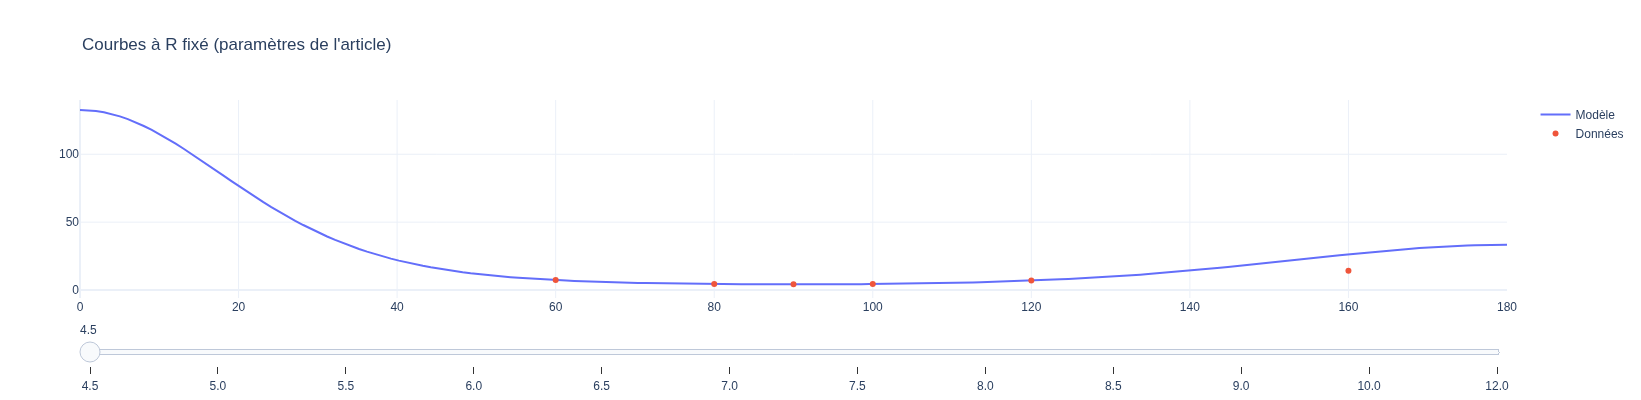

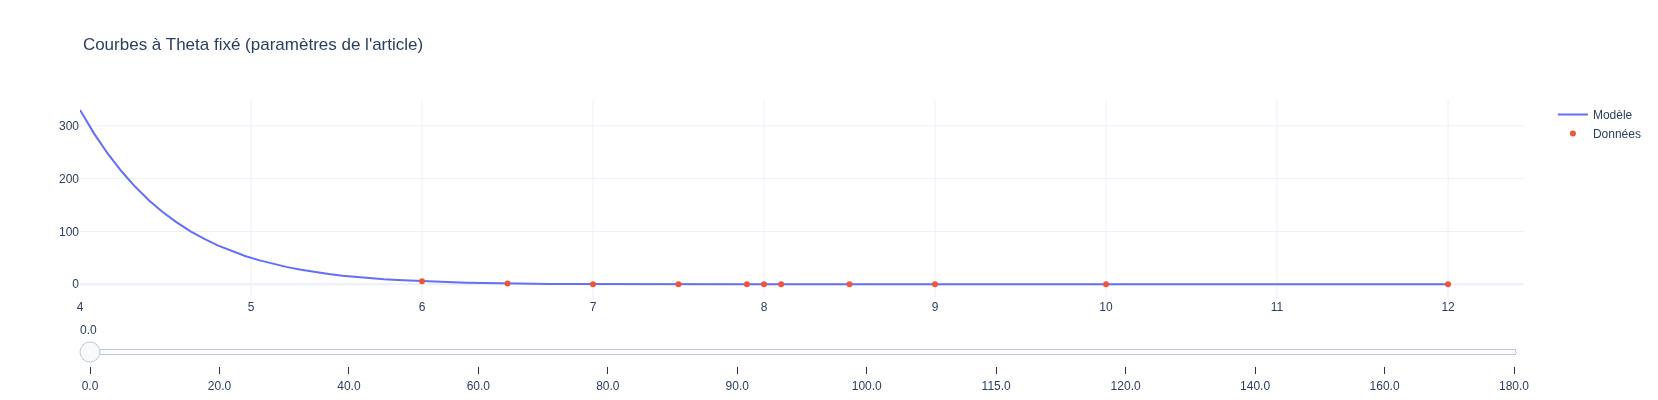

In [14]:
R_vals = np.array([4.5,5.0,5.5,6.0,6.5,7.0,7.5,8.0,8.5,9.0,10.0,12.0])
x = np.linspace(0, 180, 180)
plot_interactif(V_opt, params_He, R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé (paramètres de l'article)")
Theta_vals = np.array([0., 20., 40., 60., 80., 90., 100., 115., 120., 140., 160., 180.])
x_R = np.linspace(4, 12, 100)
plot_interactif(V_opt, params_He, Theta_vals, x_R, He,
                fixed_col="Theta", x_col="R", y_col="Energy_mEh",
                title="Courbes à Theta fixé (paramètres de l'article)",fixed_first=False)

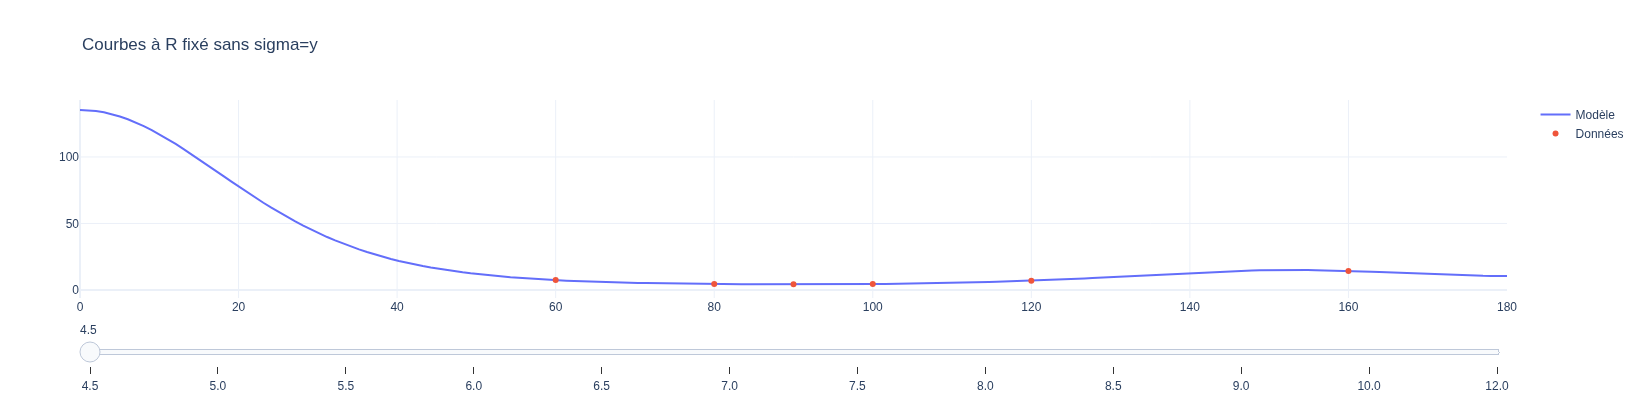

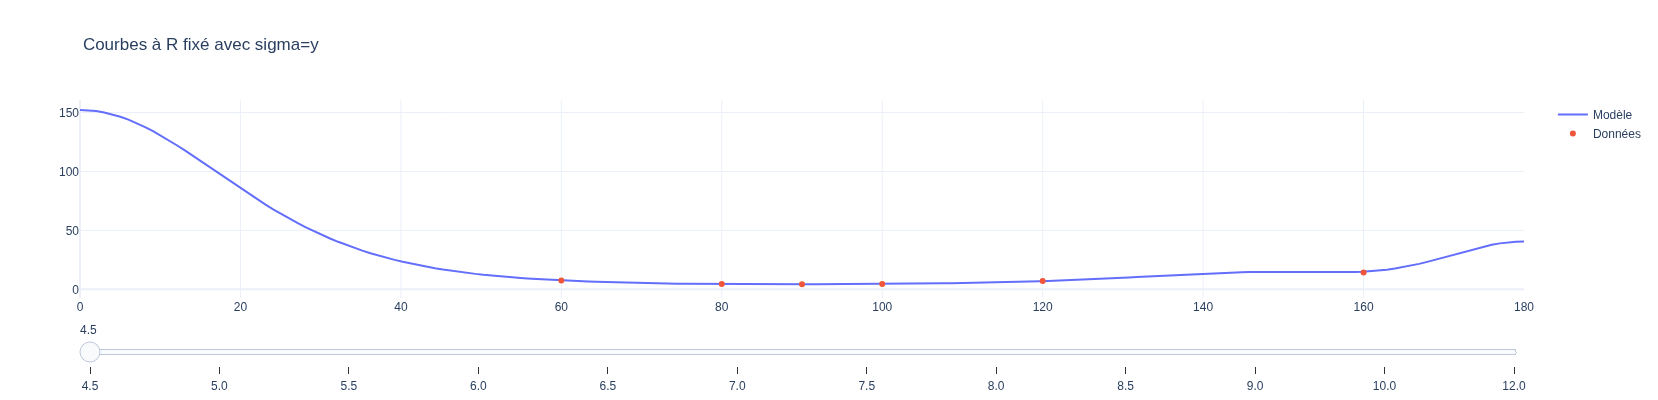

In [15]:
R_vals = np.array([4.5,5.0,5.5,6.0,6.5,7.0,7.5,8.0,8.5,9.0,10.0,12.0])
x = np.linspace(0, 180, 180)
plot_interactif(V_opt, params_opt_cf, R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé sans sigma=y")
plot_interactif(V_opt, params_opt_cf_sigma, R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé avec sigma=y")

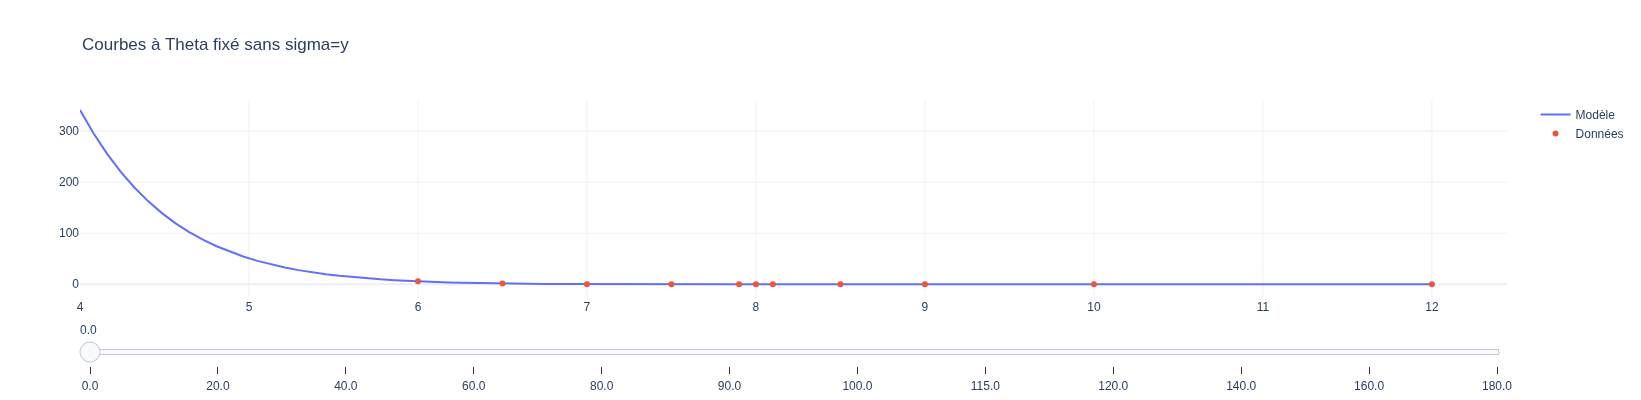

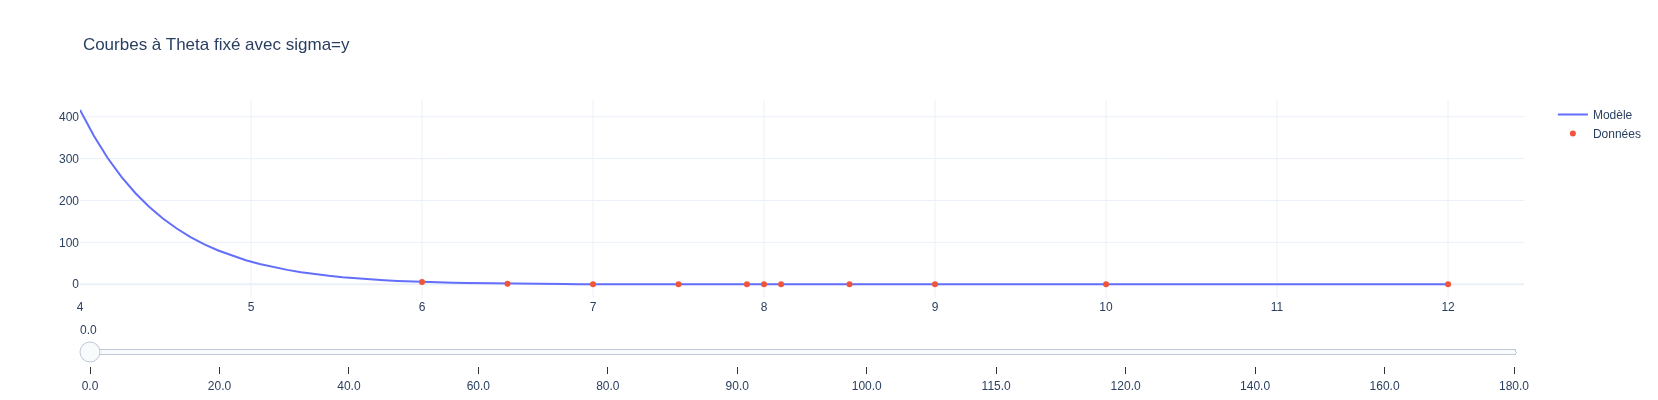

In [16]:
Theta_vals = np.array([0., 20., 40., 60., 80., 90., 100., 115., 120., 140., 160., 180.])
x_R = np.linspace(4, 12, 100)
plot_interactif(V_opt, params_opt_cf, Theta_vals, x_R, He,
                fixed_col="Theta", x_col="R", y_col="Energy_mEh",
                title="Courbes à Theta fixé sans sigma=y",fixed_first=False)
plot_interactif(V_opt, params_opt_cf_sigma, Theta_vals, x_R, He,
                fixed_col="Theta", x_col="R", y_col="Energy_mEh",
                title="Courbes à Theta fixé avec sigma=y",fixed_first=False)

In [53]:
def contour_plot(ax, params, title):
    # Axes
    theta_grid = np.linspace(0, 180, 250)
    r_grid = np.linspace(6, 10, 250)
    
    Theta_mesh, R_mesh = np.meshgrid(theta_grid, r_grid)
    
    # Calcul de Z
    Z = np.array([
        V_opt(params, np.full_like(theta_grid, r), theta_grid)
        for r in r_grid
    ])
    
    # Niveaux
    levels_to_plot = np.array([
        -0.026, -0.039,-0.051, -0.063, -0.075, -0.087,
        -0.094, -0.100, -0.112, -0.124, -0.133
    ])
    
    levels_with_labels = levels_to_plot
    
    # niveaux intermédiaires
    levels_fine = []
    for i in range(len(levels_to_plot) - 1):
        a, b = levels_to_plot[i], levels_to_plot[i + 1]
        inter = np.linspace(a, b, 6)
        levels_fine.extend(inter[1:-1])
    
    levels_fine = np.sort(np.unique(levels_fine))
    
    # Contours gris
    ax.contour(
        Theta_mesh, R_mesh, Z,
        levels=levels_fine,
        colors='gray',
        linewidths=0.7
    )
    
    # Contours principaux
    all_contours = []
    for level in levels_to_plot:
        cp = ax.contour(
            Theta_mesh, R_mesh, Z,
            levels=[level],
            colors='black',
            linewidths=1.5,
            linestyles='--'
        )
        all_contours.append(cp)
    
    # Labels
    for cp in all_contours:
        level = cp.levels[0]
        if np.isclose(levels_with_labels, level).any():
            ax.clabel(cp, fmt='%.3f', fontsize=10, inline=True)
    
    ax.set_title(f"He-HCN - Energie potentielle (mEh)\n{title}")
    ax.set_xlabel("Theta (°)")
    ax.set_ylabel("R")
    
    ax.set_yticks(np.arange(6, 10.5, 0.5))
    ax.set_xticks(np.arange(0, 181, 30))
    
    ax.grid(True, linestyle='--', alpha=0.3)

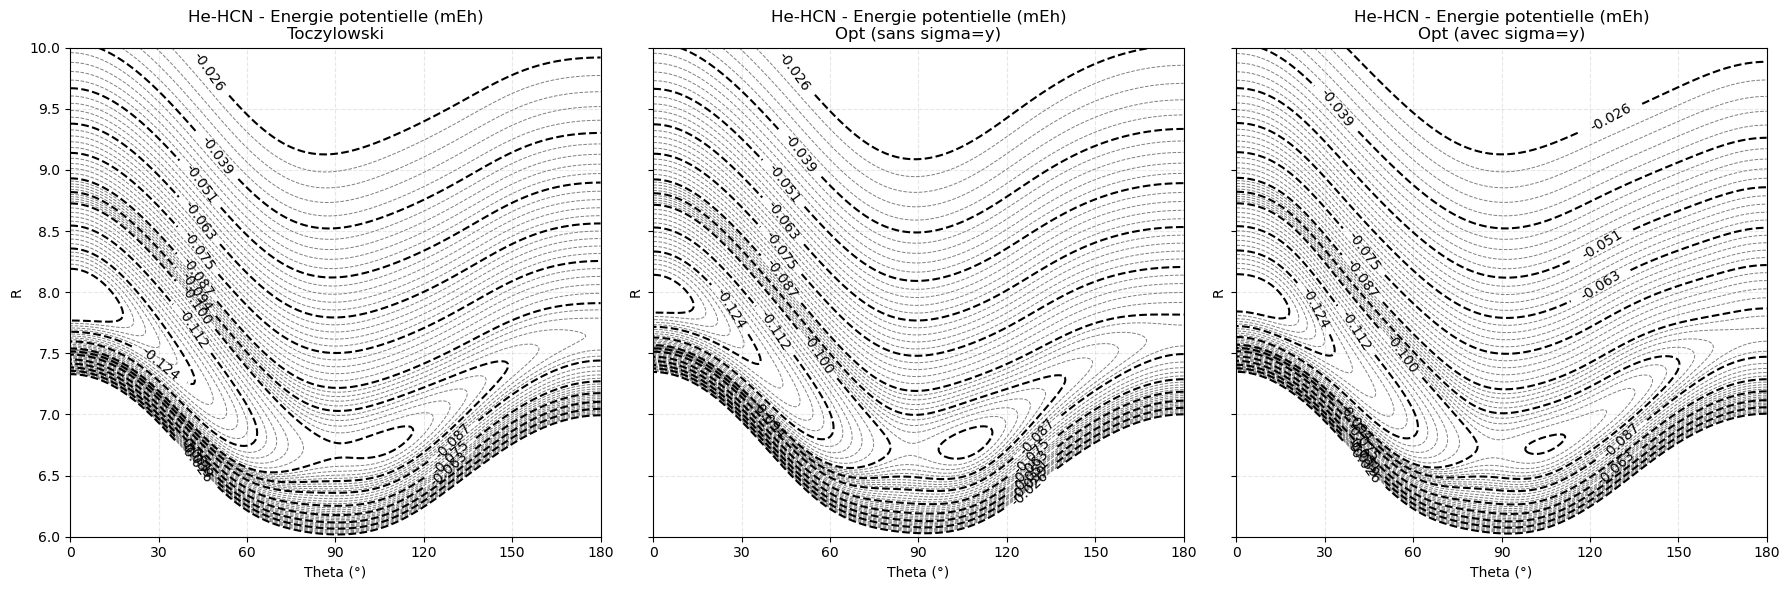

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

contour_plot(axes[0], params_He, "Toczylowski")
contour_plot(axes[1], params_opt_cf, "Opt (sans sigma=y)")
contour_plot(axes[2], params_opt_cf_sigma, "Opt (avec sigma=y)")

plt.tight_layout()

# Methode 2 : least_squares


In [18]:
def residus_He(params):
    V_pred = V_opt(params, He["R"], He["Theta"])
    # .ravel() force le résultat en un tableau 1D pour least_squares
    return (V_pred - He["Energy_mEh"]).ravel()

In [19]:
result1 = least_squares(residus_He, params_He)
params_opt_ls = result1.x

result2 = least_squares(residus_He, params_He, x_scale = "jac")
params_opt_ls_jac = result2.x

In [20]:
V_pred_ls = V_opt(params_opt_ls, R, Theta)
V_pred_ls_jac = V_opt(params_opt_ls_jac, R, Theta)

r2_ls = rsq(V_table_mEh, V_pred_ls)
r2_ls_jac = rsq(V_table_mEh, V_pred_ls_jac)

print(f"R²                 : {r2_ls}")
print(f"R² (x_scale='jac') : {r2_ls_jac}")

R²                 : 0.9999979337986399
R² (x_scale='jac') : 0.9999998710239754


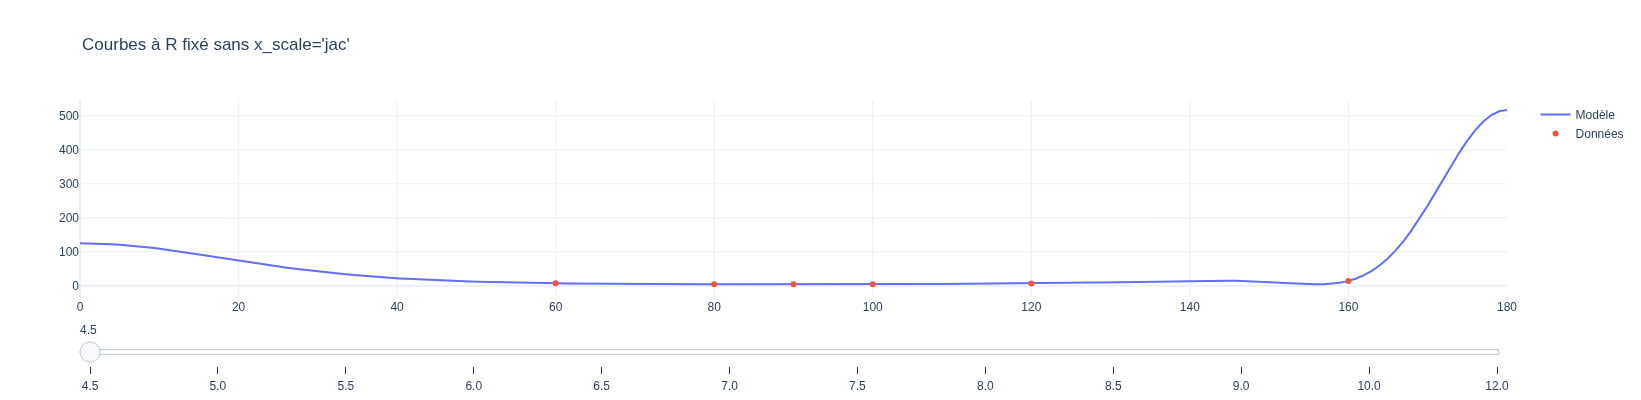

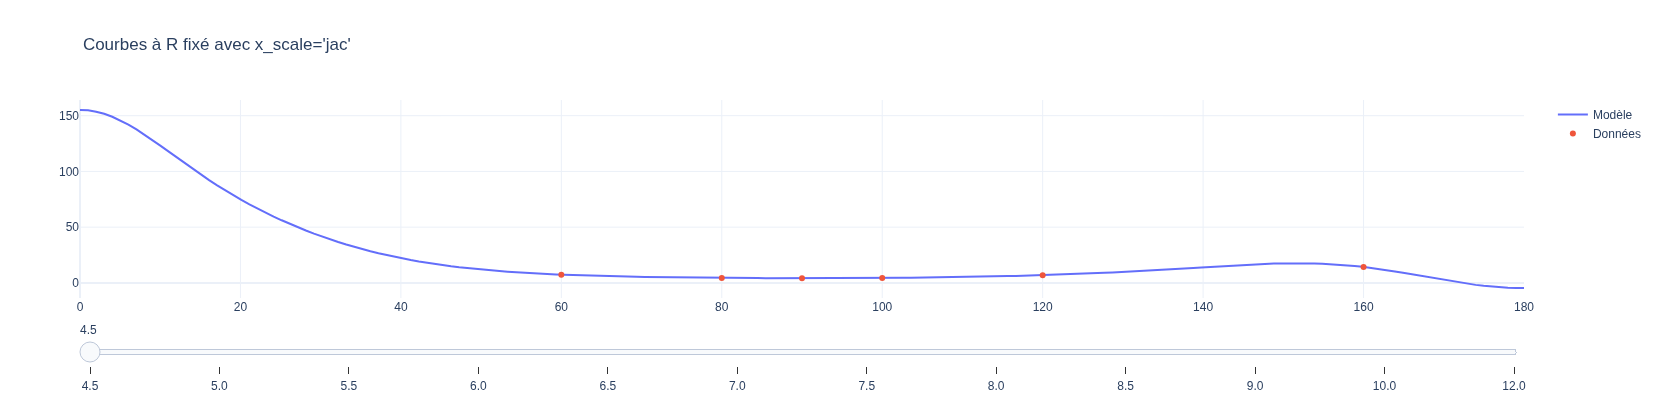

In [21]:
R_vals = np.array([4.5,5.0,5.5,6.0,6.5,7.0,7.5,8.0,8.5,9.0,10.0,12.0])
x = np.linspace(0, 180, 180)
plot_interactif(V_opt, params_opt_ls, R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé sans x_scale='jac'")
plot_interactif(V_opt, params_opt_ls_jac, R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé avec x_scale='jac'")

## Variation des params initiaux

In [22]:
def metriques(y, y_pred, params):

  residus = y - y_pred

  rss = np.sum(residus**2)
  tss = np.sum((y - np.mean(y))**2)
  r2 = 1 - rss/tss

  mae = np.mean(np.abs(residus))
  rmse = np.sqrt(np.mean(residus**2))
  param_norm = np.linalg.norm(params)

  return {
      "rmse": rmse,
      "mae": mae,
      "r2": r2,
      "rss": rss,
      "param_norm": param_norm
      }

In [23]:
nb_fits = 200

resultats = []
print("               RMSE                  r2                  mae")
for i in range(nb_fits):

  p0 = np.random.randn(40) * np.random.choice([0.1,1.0,5.0,25.0])


  try:

    res = least_squares(residus_He, p0, x_scale="jac", max_nfev=50000)

    p = res.x

    ypred = V_opt(p, He["R"], He["Theta"])

    metrics = metriques(He["Energy_mEh"], ypred, p)

    resultats.append({"params": p, **metrics})

    print(f"{i}/{nb_fits} : {metrics["rmse"]} | {metrics["r2"]} | {metrics["mae"]} |")

  except:
      pass

               RMSE                  r2                  mae
0/200 : 1.403179973972321e+34 | -4.637942197892559e+67 | 1.2091927822197213e+33 |
1/200 : 0.7117246069561888 | 0.8806774465334952 | 0.5419030224731199 |
2/200 : 0.16014635094762975 | 0.9939586684465639 | 0.05000982284181302 |
3/200 : 2.7277258992290677e+77 | -1.75266950585285e+154 | 2.373725541731146e+76 |


/home/amynek/anaconda3/envs/jupyter-2026/lib/python3.12/site-packages/scipy/optimize/_lsq/least_squares.py:965: RuntimeWarning: overflow encountered in dot
  initial_cost = 0.5 * np.dot(f0, f0)
/home/amynek/anaconda3/envs/jupyter-2026/lib/python3.12/site-packages/scipy/optimize/_lsq/trf.py:433: RuntimeWarning: overflow encountered in dot
  cost = 0.5 * np.dot(f, f)
/home/amynek/anaconda3/envs/jupyter-2026/lib/python3.12/site-packages/scipy/optimize/_lsq/common.py:595: RuntimeWarning: overflow encountered in dot
  return J.T.dot(f)
/home/amynek/anaconda3/envs/jupyter-2026/lib/python3.12/site-packages/scipy/optimize/_lsq/common.py:595: RuntimeWarning: invalid value encountered in dot
  return J.T.dot(f)
/home/amynek/anaconda3/envs/jupyter-2026/lib/python3.12/site-packages/scipy/optimize/_lsq/common.py:603: RuntimeWarning: overflow encountered in square
  scale_inv = np.sum(J**2, axis=0)**0.5
/home/amynek/anaconda3/envs/jupyter-2026/lib/python3.12/site-packages/scipy/optimize/_lsq/trf.py:

4/200 : inf | -inf | 3.1429940963951397e+305 |
5/200 : 0.16157550675454235 | 0.9938503608990072 | 0.05436409747040716 |


/tmp/ipykernel_236194/1761340803.py:34: RuntimeWarning: overflow encountered in multiply
  V_sh = np.sum(g * Pl, axis=0) * np.exp(exp_val)


6/200 : 0.0006501895957735444 | 0.9999999004185129 | 0.0004947031438436684 |
7/200 : 141324667154.50894 | -4.7047279839710916e+21 | 13043946339.397507 |
8/200 : 1.2261875454550843 | 0.6458295059290617 | 0.7121343959544951 |


...

119/200 : inf | -inf | inf |
121/200 : 1133568420.5024047 | -3.026871981467858e+17 | 164083395.8169081 |
122/200 : 0.16310012028481571 | 0.9937337583529168 | 0.0563749871535072 |
123/200 : 0.3858408909228553 | 0.9649316704208801 | 0.23001620560206312 |
124/200 : 361.54533830290467 | -30790.02231297632 | 33.22549253942584 |
125/200 : 0.9519717991322143 | 0.7865251375314437 | 0.639626839860829 |
127/200 : 0.41175704682821695 | 0.9600625200998743 | 0.24898348575323592 |
129/200 : 8.534457553166268 | -16.157358328405888 | 2.4777464415918007 |
130/200 : 0.5961500404976866 | 0.916283756670836 | 0.3847972080672043 |
131/200 : 0.5791177126657929 | 0.9209990574848304 | 0.41672326682981625 |
132/200 : 0.16540612995226417 | 0.9935553137830883 | 0.05826583277697713 |
133/200 : 0.33849841555279203 | 0.9730094424231596 | 0.21568007392120242 |
134/200 : 3.3326930803278916e+108 | -2.6163100868290768e+216 | 2.8706503471421413e+107 |
135/200 : inf | -inf | 3.7327361451287807e+287 |
136/200 : 0.160223285

/home/amynek/anaconda3/envs/jupyter-2026/lib/python3.12/site-packages/scipy/optimize/_lsq/common.py:113: RuntimeWarning: invalid value encountered in divide
  p_norm = norm(suf / denom)
/home/amynek/anaconda3/envs/jupyter-2026/lib/python3.12/site-packages/scipy/optimize/_lsq/common.py:115: RuntimeWarning: invalid value encountered in divide
  phi_prime = -np.sum(suf ** 2 / denom**3) / p_norm


158/200 : inf | -inf | 7.247799850619409e+175 |
159/200 : 0.0006501895963886345 | 0.9999999004185127 | 0.0004947009748094259 |
160/200 : 0.16310012288340234 | 0.9937337581532435 | 0.05637151429603251 |
161/200 : inf | -inf | 4.174241201473805e+304 |
162/200 : 0.15923939381432595 | 0.9940269024519149 | 0.04559562081248893 |
163/200 : 0.16157550632127216 | 0.9938503609319882 | 0.05436437533817879 |
164/200 : 5.347726577103318 | -5.736541110287686 | 1.1748461748775265 |
165/200 : 0.47975848044232855 | 0.9457819496434741 | 0.32267416971040624 |
166/200 : 7.360862514899894e+99 | -1.2763094601464332e+199 | 6.427954003927852e+98 |
167/200 : 1.762636567304901 | 0.26814654508267177 | 0.6029761562897058 |
168/200 : 0.6040335552144989 | 0.914054982093955 | 0.44810906363213954 |
169/200 : 0.16310013011793814 | 0.9937337575973475 | 0.056367292766143696 |
170/200 : 0.16010428264992466 | 0.9939618419831711 | 0.04979768354909615 |
171/200 : 0.1614232057370804 | 0.99386194873052 | 0.05502389662948133 |

/home/amynek/anaconda3/envs/jupyter-2026/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


199/200 : 4.608441944733767e+106 | -5.002727157399049e+212 | 3.9509584284425734e+105 |
